# Cropping

Implements the third stage of *[Automated Low-Cost Photogrammetric Acquisition of 3D Models from
Small Form-Factor Artefacts](https://www.mdpi.com/2079-9292/8/12/1441)* (Collins et al., 2019),
following on from [dense_reconstruction.ipynb](dense_reconstruction.ipynb).

> Cropping is the removal of unwanted points that do not form part of the object being
> acquired&mdash;mostly points representing the turntable and calibration pattern and any
> supporting material used to stabilise the object during the acquisition. A dark coloured
> supporting foam material was chosen to contrast with the much lighter colour of the cuneiform
> fragments so that it could be automatically identified and removed. The calibration model used
> during bundle adjustment lies on the z = 0 plane, so most of the extraneous points lie outside
> an axis-aligned bounding box with an x and y extent equal to the size of the calibration pattern
> and a z extent from the maximum z-coordinate in the point-cloud down to a few millimetres above
> the turntable surface. The actual lower z-limit used is derived by progressively calculating the
> average luminosity of points in millimetre-by-millimetre slices starting at z = 2 mm above the
> turntable and increasing z until an average luminosity threshold is exceeded.

**Pipeline in this notebook:**
1. Load Step 5's own raw, **unfiltered** StereoFusion output (`outputs/<set>/dense/fused`) - not
   `dense_raw.ply`, which already applied Step 5's own rough *spherical* ROI filter as a stand-in
   for this exact stage (see that notebook's Step 5). Starting from the unfiltered cloud gives the
   x/y box crop below real work to do: a phone-camera capture reconstructs plenty of turntable rim
   and background well outside the calibration pattern.
2. **Correct a known Step 4 orientation bug** (Step 2 below) - this replica's real-camera
   reconstruction comes out mirrored through the z = 0 plane, artefact-below-turntable instead of
   above it.
3. **x/y crop** to an axis-aligned square the size of the calibration pattern (130&times;130&nbsp;mm,
   centred at the world origin - the same plane the pattern is defined on during calibration).
4. **z lower-limit search**: starting 2&nbsp;mm above the turntable (z&nbsp;=&nbsp;0, the
   calibration model's own plane from Step 4), slide a 1&nbsp;mm-thick slab upward, averaging the
   luminosity of the points inside it, until that average exceeds a threshold - the paper's method
   for finding where dark supporting material ends and the (much lighter) artefact begins.
5. **z upper-limit via a density gap** (Step 5 below) - not in the paper, added for this replica:
   StereoFusion consistently leaves a small blob of disconnected debris floating well above the
   artefact (almost certainly a specular-highlight fusion ghost). A gap in point density between
   the artefact's own mass and that debris is used to cut it.
6. **Crop** to the resulting box and write the cropped, coloured point cloud to
   `outputs/<set>/cropped/cropped.ply`, ready for Step 7 (Point Cloud Registration).

**Notes on this replica:**
- The images in `images/set_*` were captured with the miniature sitting directly on the
  calibration pattern - no dark foam raiser underneath it, unlike the paper's cuneiform-fragment
  setup. It turns out not to matter much in practice: the model's own paint sits darker near its
  base and lightens further up, which is enough of a luminosity gradient for the paper's sweep to
  find a sensible lower limit anyway (see Step 4 below).
- The floating-debris cutoff (Step 5) is this replica's own addition, not the paper's - it exists
  because this specific capture/reconstruction setup consistently produces one small disconnected
  cluster of junk points per set. It's a simple, generic density-gap heuristic, not a general
  outlier remover - the paper's own remaining pruning work (Step 8, Merge and Pruning) still has a
  job to do on whatever survives cropping.

In [1]:
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pycolmap

from utils import cropping as cr
from utils import dense_reconstruction as dr

## Parameters

In [2]:
SET_NAME = "set_3"

ROOT = Path.cwd()
FUSED_DIR = ROOT / "outputs" / SET_NAME / "dense" / "fused"  # Step 5's raw, unfiltered fusion output
OUT_DIR = ROOT / "outputs" / SET_NAME / "cropped"
OUT_PLY = OUT_DIR / "cropped.ply"

# Calibration pattern footprint (Step 1/4) - the crop box's x/y extent.
PATTERN_SIZE_MM = 130.0

# z lower-limit search (paper spec: 2mm start offset, 1mm slices).
TURNTABLE_Z_MM = 0.0  # the calibration model's own z=0 plane, fixed during Step 4's bundle adjustment
Z_START_OFFSET_MM = 2.0
Z_SLICE_THICKNESS_MM = 1.0
LUMINOSITY_THRESHOLD = 100.0  # see Step 4's profile plot for why this separates the plate/base shadow from the model above

# z upper-limit: cut off at the first density gap this thick, once point density drops
# below this many points/slice - see Step 5. Not paper spec; see the notebook intro.
GAP_THICKNESS_MM = 5.0
MIN_POINTS_PER_SLICE = 5

if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
OUT_DIR.mkdir(parents=True)

## Step 1 - Load Step 5's raw dense point cloud

The unfiltered StereoFusion output - every point PatchMatchStereo + StereoFusion produced,
including the turntable, calibration pattern, and any background dense stereo happened to
reconstruct.

In [3]:
fused = pycolmap.Reconstruction()
fused.read(str(FUSED_DIR))
points, colors = dr.points_and_colors(fused)

print(f"raw fused points: {len(points):,}")
print("bounding box min (mm):", points.min(axis=0))
print("bounding box max (mm):", points.max(axis=0))

radii = np.linalg.norm(points[:, :2], axis=1)
print(f"points beyond the pattern's half-diagonal ({PATTERN_SIZE_MM/2:.0f}mm radius from origin): "
      f"{(radii > PATTERN_SIZE_MM/2).sum():,} / {len(points):,}")

raw fused points: 1,219,180
bounding box min (mm): [-224.09185791 -200.25404358  -83.20968628]
bounding box max (mm): [164.38040161 193.9559021   89.84890747]
points beyond the pattern's half-diagonal (65mm radius from origin): 816,515 / 1,219,180


## Step 2 - Correct a known Step 4 orientation bug

The real-camera reconstruction from Step 4 comes out **mirrored through the z&nbsp;=&nbsp;0
plane**: instead of the artefact sitting above the turntable (positive z, towards the camera),
it reconstructs *below* it. This is Step 4's own coplanar-target pose ambiguity (see
`plate_geometry.look_at_origin`'s docstring - "two camera centres related by reflection through
the Z=0 plane... produce the two poses a coplanar point set cannot distinguish by reprojection
error alone") resolving to the wrong sign for this capture rig. It isn't specific to this
notebook either - the same downward-hanging cluster is already visible, unflipped, in Step 5's own
diagnostic plot.

`cropping.correct_z_axis_inversion` negates z to restore the convention the rest of this notebook
(and the paper) assumes. This is a workaround at the data-consumption end - the proper fix belongs
in `colmap_calibration.py`'s pose disambiguation - but it lets this step produce a correct crop
today without re-running Steps 4-5.

In [4]:
raw_points = points.copy()
points = cr.correct_z_axis_inversion(points)
print("z range before correction:", f"{raw_points[:, 2].min():.1f} .. {raw_points[:, 2].max():.1f}")
print("z range after correction: ", f"{points[:, 2].min():.1f} .. {points[:, 2].max():.1f}")

z range before correction: -83.2 .. 89.8
z range after correction:  -89.8 .. 83.2


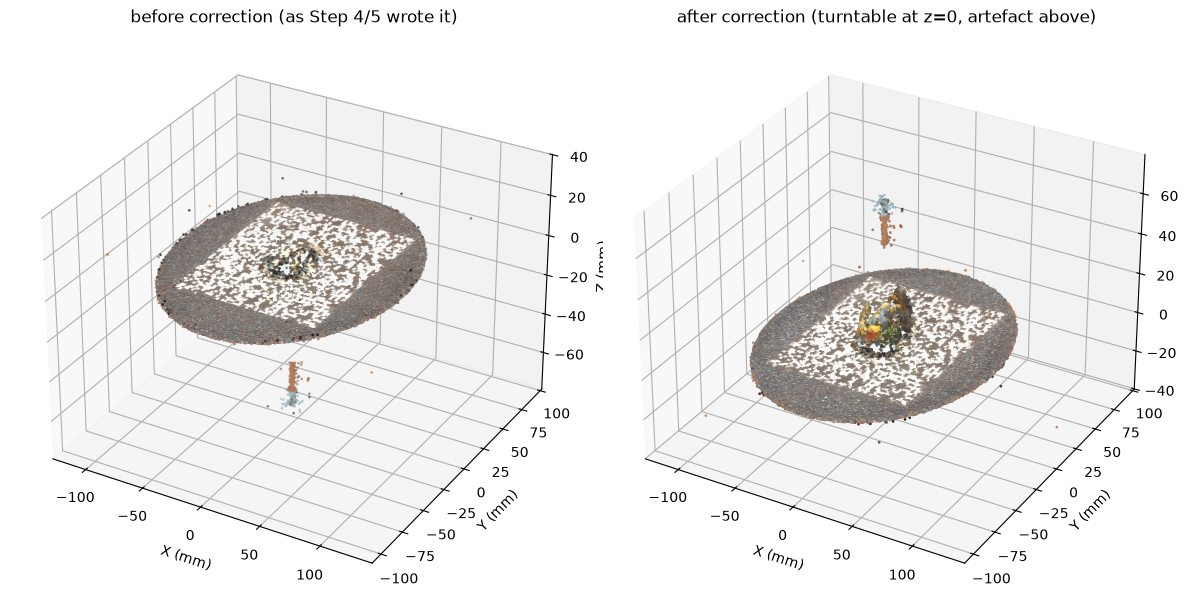

In [5]:
fig = plt.figure(figsize=(12, 6))
for i, (p, title) in enumerate([(raw_points, "before correction (as Step 4/5 wrote it)"),
                                  (points, "after correction (turntable at z=0, artefact above)")]):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    sample = np.random.default_rng(0).choice(len(p), size=min(60_000, len(p)), replace=False)
    ax.scatter(p[sample, 0], p[sample, 1], p[sample, 2], c=colors[sample] / 255.0, s=1)
    ax.set_xlabel("X (mm)"); ax.set_ylabel("Y (mm)"); ax.set_zlabel("Z (mm)")
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Step 3 - x/y crop to the calibration pattern's footprint

Keeps only points whose (x, y) falls inside the pattern's own 130&times;130&nbsp;mm square,
centred at the world origin. This alone discards most of the turntable rim and background
clutter picked up by dense stereo matching outside the pattern.

In [6]:
xy_points, xy_colors, xy_mask = cr.crop_xy(points, colors, PATTERN_SIZE_MM)
print(f"x/y crop: {len(xy_points):,} / {len(points):,} points kept "
      f"({len(xy_points)/len(points):.1%})")
print("kept bounding box min/max (mm):", xy_points.min(axis=0), xy_points.max(axis=0))

x/y crop: 600,871 / 1,219,180 points kept (49.3%)
kept bounding box min/max (mm): [-64.99969482 -64.99965668  -5.60182953] [64.99980164 64.99993134 83.20968628]


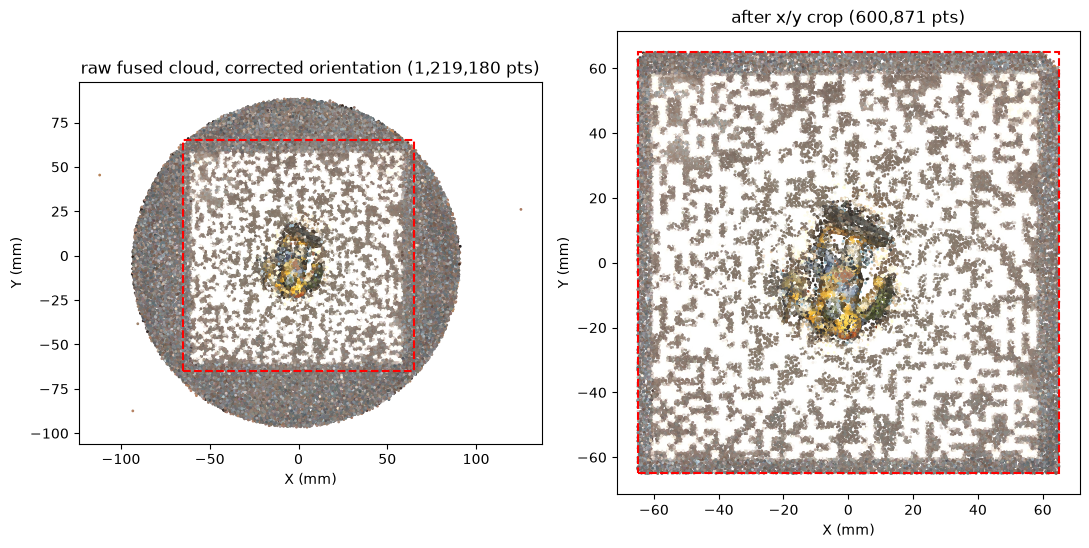

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
for ax, (p, c, title) in zip(axes, [
    (points, colors, f"raw fused cloud, corrected orientation ({len(points):,} pts)"),
    (xy_points, xy_colors, f"after x/y crop ({len(xy_points):,} pts)"),
]):
    sample = np.random.default_rng(0).choice(len(p), size=min(60_000, len(p)), replace=False)
    ax.scatter(p[sample, 0], p[sample, 1], c=c[sample] / 255.0, s=1)
    half = PATTERN_SIZE_MM / 2.0
    ax.add_patch(plt.Rectangle((-half, -half), PATTERN_SIZE_MM, PATTERN_SIZE_MM,
                                fill=False, edgecolor="red", linewidth=1.5, linestyle="--"))
    ax.set_title(title)
    ax.set_xlabel("X (mm)"); ax.set_ylabel("Y (mm)")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Step 4 - Luminosity profile and the z lower-limit search

Sliding a 1&nbsp;mm slab upward from 2&nbsp;mm above the (now-corrected) turntable, computing
each slab's mean point luminosity (Rec.&nbsp;601 luma), until it exceeds `LUMINOSITY_THRESHOLD`.
Computed on the x/y-cropped points only, so background outside the pattern can't skew a slab's
average.

In [8]:
z_limit, profile, reached_threshold = cr.find_lower_z_limit(
    xy_points, xy_colors,
    turntable_z=TURNTABLE_Z_MM,
    start_offset_mm=Z_START_OFFSET_MM,
    slice_thickness_mm=Z_SLICE_THICKNESS_MM,
    luminosity_threshold=LUMINOSITY_THRESHOLD,
)
print(f"z lower limit: {z_limit:.1f}mm (threshold {'exceeded' if reached_threshold else 'NOT reached - fell back to the start offset'})")
print(f"{len(profile)} slice(s) examined between {Z_START_OFFSET_MM:.0f}mm and the cloud's max z")

if reached_threshold and z_limit <= TURNTABLE_Z_MM + Z_START_OFFSET_MM + Z_SLICE_THICKNESS_MM:
    print("\nThreshold was exceeded already in the very first slab - the z-crop below reduces to "
          "'keep everything from 2mm above the plate up'.")

z lower limit: 6.0mm (threshold exceeded)
82 slice(s) examined between 2mm and the cloud's max z


## Step 5 - z upper-limit: trim disconnected debris

Not part of the paper's method. This replica's dense reconstruction consistently leaves one
small, disconnected clump of points floating well above the artefact - visible as a gap in the
"points per slice" chart below between the artefact's own tapering mass and that clump. Cutting
at the first `GAP_THICKNESS_MM`-thick run of near-empty slices keeps the artefact (including any
genuinely thin extremities that taper off gradually) while dropping the disconnected debris.

In [9]:
z_max = float(xy_points[:, 2].max())
z_upper_limit = cr.find_upper_z_limit(
    profile, fallback_z_max=z_max,
    gap_thickness_mm=GAP_THICKNESS_MM, min_points_per_slice=MIN_POINTS_PER_SLICE,
)
if z_upper_limit < z_max:
    print(f"density gap found: cutting at z={z_upper_limit:.1f}mm (cloud's own max was {z_max:.1f}mm)")
else:
    print(f"no density gap found up to {z_max:.1f}mm - nothing above the artefact to cut")

density gap found: cutting at z=24.0mm (cloud's own max was 83.2mm)


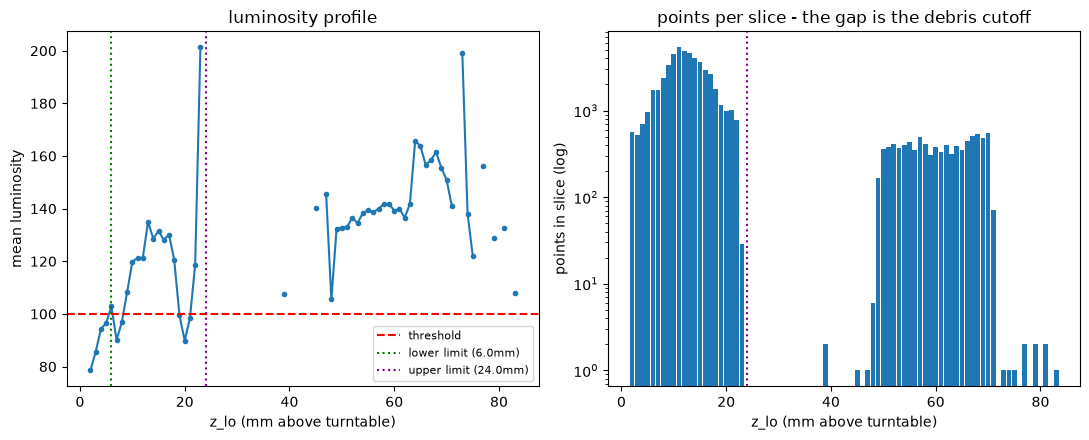

In [10]:
z_los = [s.z_lo for s in profile]
mean_lums = [s.mean_luminosity for s in profile]
counts = [s.num_points for s in profile]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True)
axes[0].plot(z_los, mean_lums, marker="o", markersize=3)
axes[0].axhline(LUMINOSITY_THRESHOLD, color="red", linestyle="--", label="threshold")
axes[0].axvline(z_limit, color="green", linestyle=":", label=f"lower limit ({z_limit:.1f}mm)")
axes[0].axvline(z_upper_limit, color="purple", linestyle=":", label=f"upper limit ({z_upper_limit:.1f}mm)")
axes[0].set_xlabel("z_lo (mm above turntable)"); axes[0].set_ylabel("mean luminosity")
axes[0].set_title("luminosity profile"); axes[0].legend(fontsize=8)

axes[1].bar(z_los, counts, width=Z_SLICE_THICKNESS_MM * 0.9)
axes[1].axvline(z_upper_limit, color="purple", linestyle=":")
axes[1].set_yscale("log")
axes[1].set_xlabel("z_lo (mm above turntable)"); axes[1].set_ylabel("points in slice (log)")
axes[1].set_title("points per slice - the gap is the debris cutoff")
plt.tight_layout()
plt.show()

## Step 6 - Apply the crop

x/y box + z from the derived lower limit up to the derived upper limit.

In [11]:
cropped_points, cropped_colors, crop_mask = cr.crop_to_pattern_and_z(
    points, colors, PATTERN_SIZE_MM, z_limit, z_upper_limit
)
print(f"cropped: {len(cropped_points):,} / {len(points):,} points kept "
      f"({len(cropped_points)/len(points):.2%})")
if len(cropped_points):
    print("cropped bounding box min/max (mm):", cropped_points.min(axis=0), cropped_points.max(axis=0))

cr.write_ply(OUT_PLY, cropped_points, cropped_colors)
print(f"wrote {OUT_PLY}")

cropped: 47,524 / 1,219,180 points kept (3.90%)
cropped bounding box min/max (mm): [-56.04425812 -54.64585114   6.00292397] [58.42205811 59.73364258 23.30277252]
wrote /mnt/c/Users/gnoceras/Documents/GustavoPersonal/ScanningTable/outputs/set_3/cropped/cropped.ply


## Before / after 3D scatter

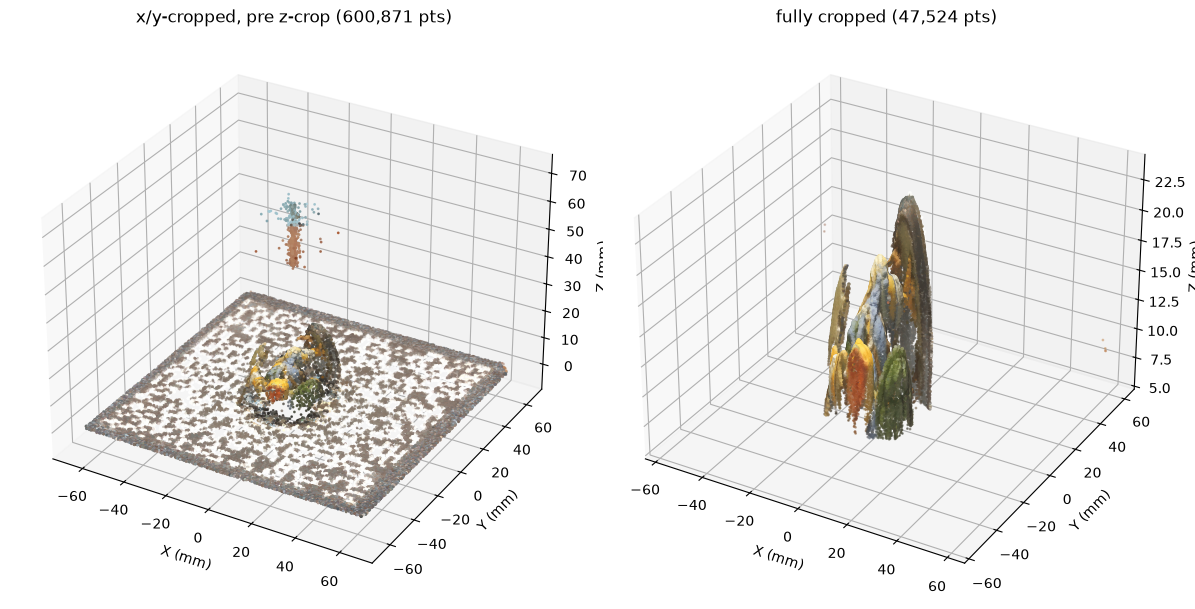

In [12]:
fig = plt.figure(figsize=(12, 6))
for i, (p, c, title) in enumerate([
    (xy_points, xy_colors, f"x/y-cropped, pre z-crop ({len(xy_points):,} pts)"),
    (cropped_points, cropped_colors, f"fully cropped ({len(cropped_points):,} pts)"),
]):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    if len(p):
        sample = np.random.default_rng(0).choice(len(p), size=min(40_000, len(p)), replace=False)
        ax.scatter(p[sample, 0], p[sample, 1], p[sample, 2], c=c[sample] / 255.0, s=1)
    ax.set_xlabel("X (mm)"); ax.set_ylabel("Y (mm)"); ax.set_zlabel("Z (mm)")
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Summary

In [13]:
print(f"{SET_NAME}")
print(f"  raw fused points:        {len(points):,}")
print(f"  after x/y crop:          {len(xy_points):,}")
print(f"  z lower limit:           {z_limit:.1f}mm ({'threshold exceeded' if reached_threshold else 'fallback to start offset'})")
print(f"  z upper limit:           {z_upper_limit:.1f}mm (cloud max was {z_max:.1f}mm)")
print(f"  after full crop:         {len(cropped_points):,}")
print(f"  wrote:                   {OUT_PLY}")

set_3
  raw fused points:        1,219,180
  after x/y crop:          600,871
  z lower limit:           6.0mm (threshold exceeded)
  z upper limit:           24.0mm (cloud max was 83.2mm)
  after full crop:         47,524
  wrote:                   /mnt/c/Users/gnoceras/Documents/GustavoPersonal/ScanningTable/outputs/set_3/cropped/cropped.ply
